#### 주성분 분석(PCA:Principal Component Analysis)
: 고차원의 데이터를 저차원의 데이터로 환원시키는 기법 

In [1]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [3]:
# 3차원 -> 2차원 데이터로 변경
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

---
#### PCA 모델 구성하기

In [4]:
from sklearn.decomposition import PCA

In [5]:
pca = PCA(n_components=50)
# 300개의 데이터중 Feature의 특징을 포함하여 확실한 주성분 50개를 선택 
pca.fit(fruits_2d)

PCA(n_components=50)

In [6]:
pca.components_.shape

(50, 10000)

In [7]:
import matplotlib.pyplot as plt

In [8]:
# 시각화 함수
def draw_fruits(arr, ratio=1): # ratio:해상도 크기 
    n = len(arr) # n은 샘플 갯수 
    # 한줄에 10개씩 이미지를 그린다.
    rows = int(np.ceil(n/10)) # 올림처리 
    cols = n if rows < 2 else 10 # 행이 1개이면 열 갯수가 샘플갯쉬고 그렇지 않으면 10개 이다.
    _, axs = plt.subplots(
                        rows,
                        cols,
                        figsize=(cols*ratio, rows*ratio),
                        squeeze=False
                )
    for i in range(rows):
        for j in range(cols):
            if i*10+j < n:
                axs[i,j].imshow(arr[i*10+j], cmap='gray')
            axs[i,j].axis('off')
    plt.show()

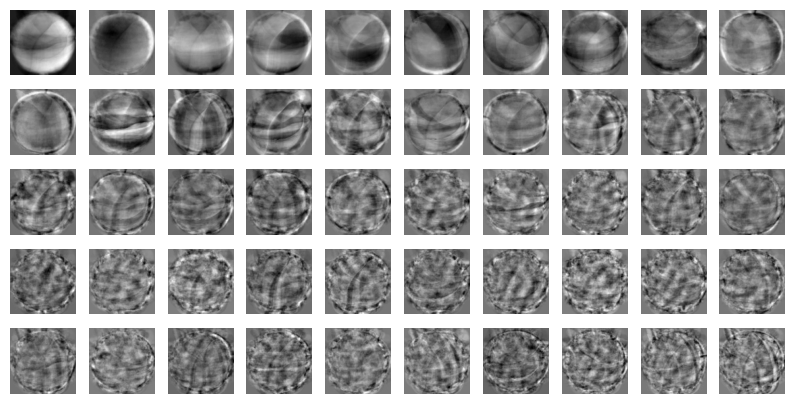

In [9]:
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [11]:
# 행의 갯수는 원본과 동일하게 하고 Feature의 특성을 50개의 주성분으로 변경하기
print(fruits_2d.shape)
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 10000)
(300, 50)


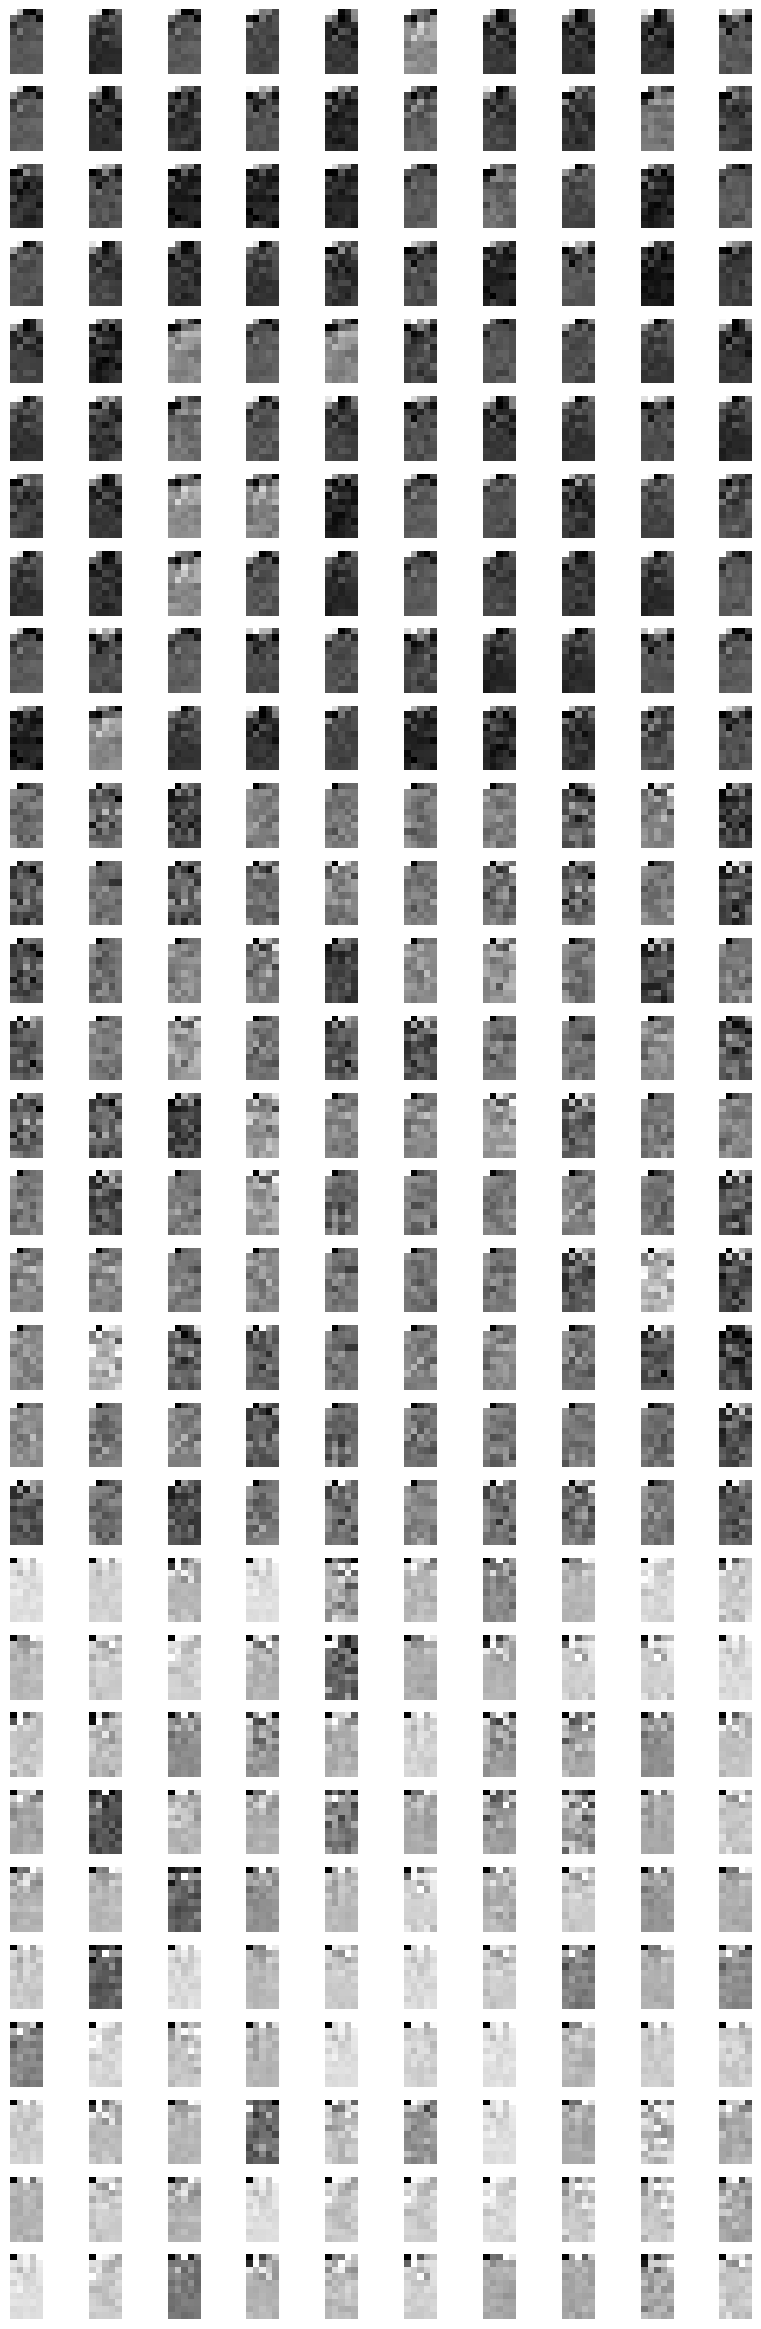

In [12]:
draw_fruits(fruits_pca.reshape(-1, 10, 5))

----
#### 원본 데이터 재구성

In [13]:
fruits_inverse = pca.inverse_transform(fruits_pca)
fruits_inverse.shape

(300, 10000)

In [14]:
# 그림을 그리기 위해 2차원 확장
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
fruits_reconstruct.shape

(300, 100, 100)

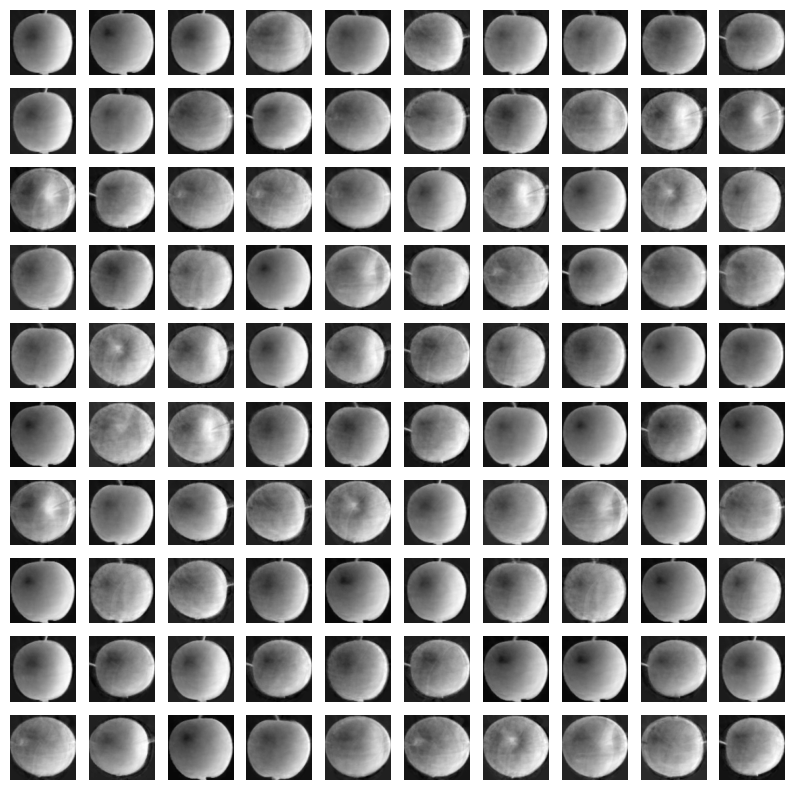

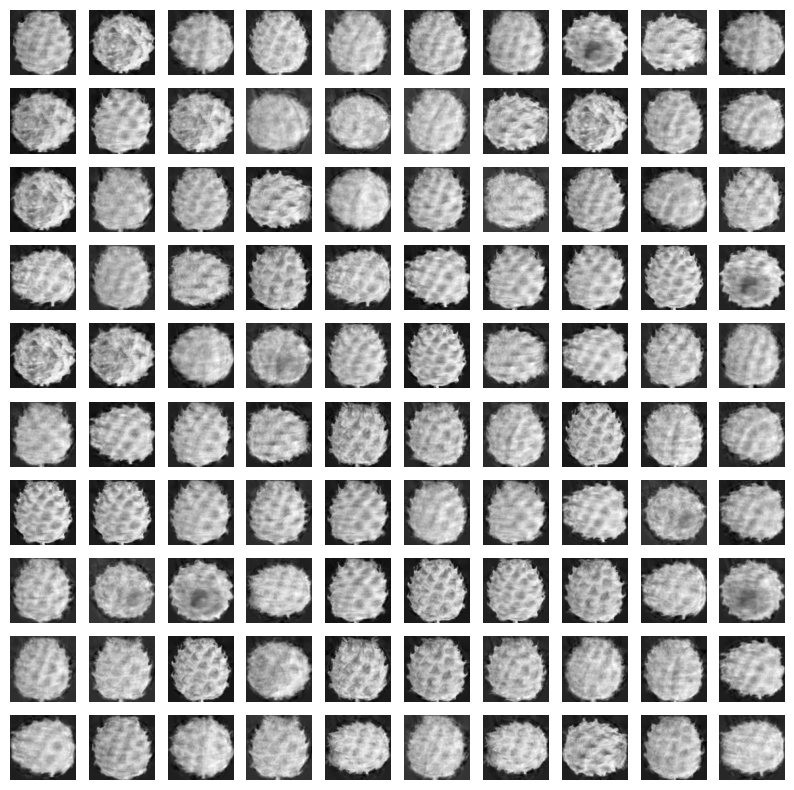

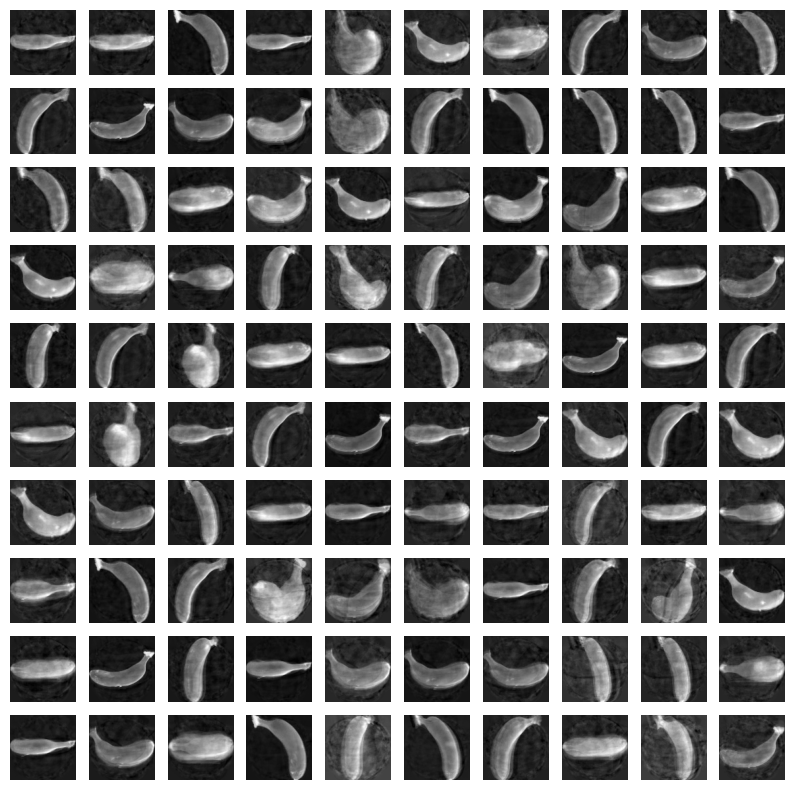

In [15]:
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print("\n")

> 1/200의 데이터 특성만 가지고도 전반적으로 배경은 깨끗하지 않으나 물체의 구분은 가능하다.

----
#### 설명된 분산 
: 주성분으로 구성할때 원본 데이터의 분산을 어느정도 유지하고 있는지 확인하는 방법

In [16]:
np.sum(pca.explained_variance_ratio_) # 50개의 주성분 데이터 

0.9223034626166872

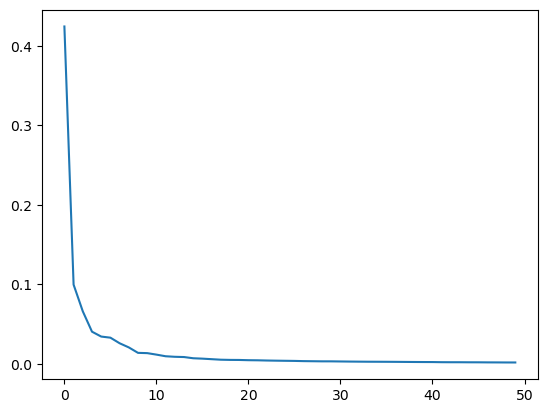

In [17]:
# 그래프 그리기
plt.plot(pca.explained_variance_ratio_)
plt.show()

> 10개의 주성분만 선정해도 문제 없을 것 같아 보인다.

---
#### 주성분을 10개만 선정해서 해보자

In [18]:
pca10 = PCA(n_components=10)
pca10.fit(fruits_2d)

PCA(n_components=10)

In [19]:
fruits_pca10 = pca10.transform(fruits_2d)
fruits_pca10.shape

(300, 10)

In [20]:
fruits_inverse10 = pca10.inverse_transform(fruits_pca10)
fruits_inverse10.shape

(300, 10000)

In [21]:
fruits_reconstruct10 = fruits_inverse10.reshape(-1, 100, 100)
fruits_reconstruct10.shape

(300, 100, 100)

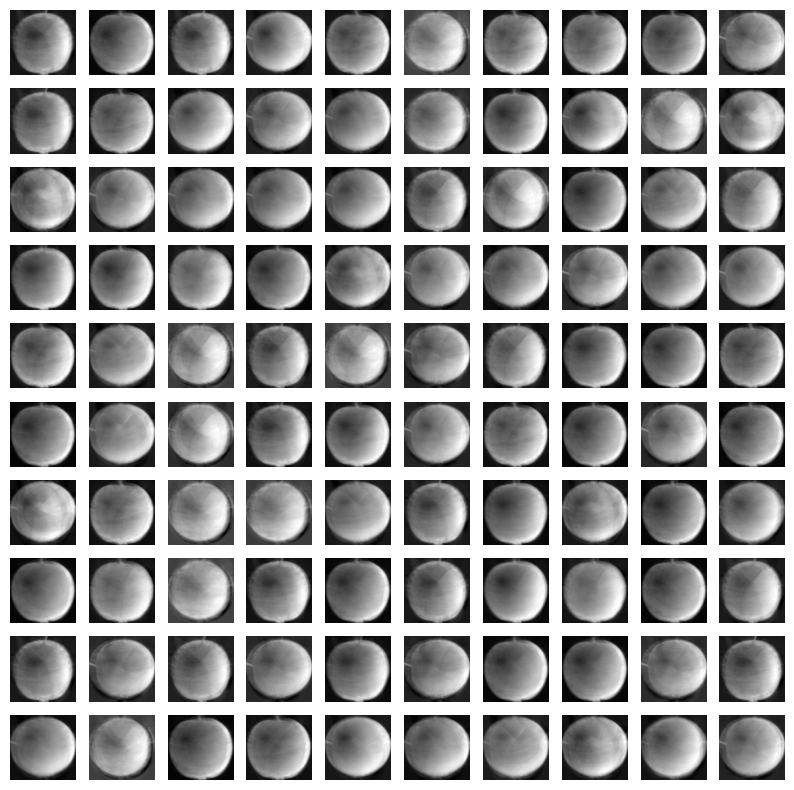

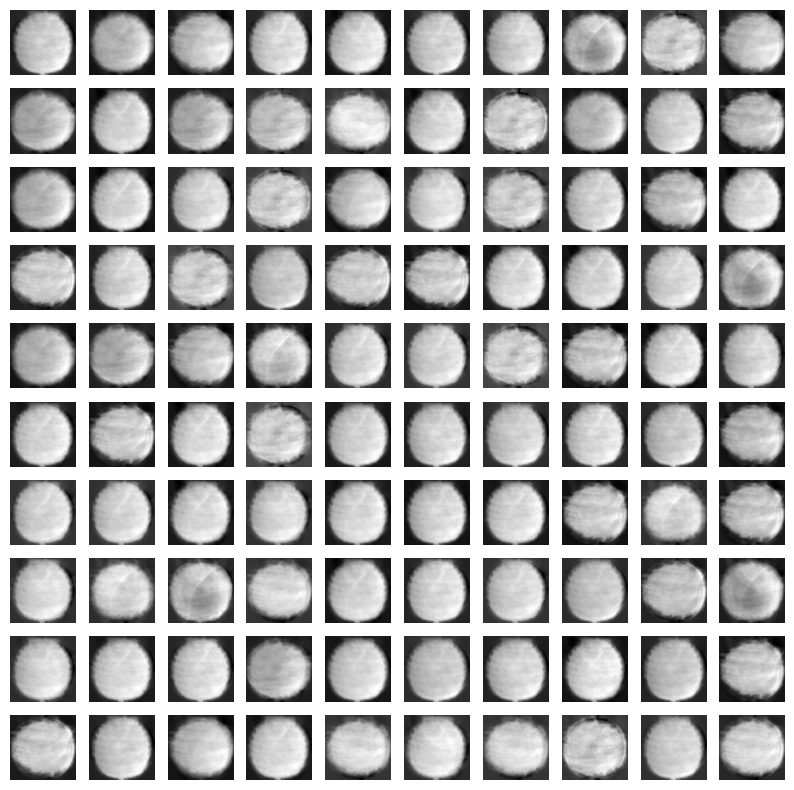

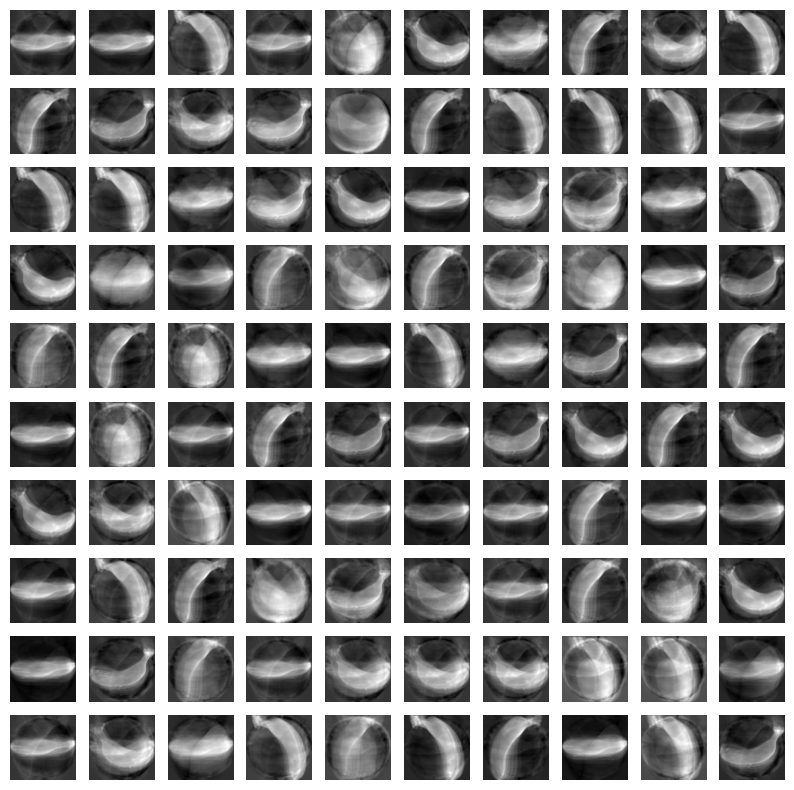

In [22]:
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct10[start:start+100])
    print("\n")

In [23]:
np.sum(pca10.explained_variance_ratio_)

0.7711096083264372

---
#### 로지스틱 회귀분석에 주성분분석을 대입하여 사용해 보기

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
lr = LogisticRegression()

In [26]:
# 로지스틱 지도학습 target이 필요
target = np.array([0]*100 + [1]*100 + [2]*100)
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [27]:
# 교차검증을 통해 실시
from sklearn.model_selection import cross_validate

In [ ]:
# 300 * 10000
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.13357715606689452


In [29]:
# 300 * 50
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.010942459106445312


In [30]:
# 300 * 10
scores = cross_validate(lr, fruits_pca10, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.009529352188110352


In [31]:
scores

{'fit_time': array([0.008003  , 0.00982809, 0.0120008 , 0.0014441 , 0.01637077]),
 'score_time': array([0.00100017, 0.        , 0.        , 0.        , 0.        ]),
 'test_score': array([1.        , 1.        , 1.        , 0.98333333, 1.        ])}

----
#### 주성분 분석의 분산의 크기를 정해 사용하기 

In [32]:
pca = PCA(n_components=0.5) # n_components가 실수를 정하면 분산의 percent로 알고 있다. 
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [33]:
pca.n_components_

2

In [34]:
fruits_pca = pca.transform(fruits_2d)
fruits_pca.shape

(300, 2)

In [36]:
# 교차검증으로 확인
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.02758054733276367


In [37]:
# 주성분의 값을 알아보자
pcaComponents = pca.fit_transform(fruits_2d)

In [38]:
import pandas as pd

In [39]:
pcadf = pd.DataFrame(data=pcaComponents, columns=['PCA1','PCA2'])
pcadf.head()

,PCA1,PCA2
0,2776.498471,1580.322486
1,3075.909684,2734.476728
2,2616.828977,1496.477291
3,3113.625578,2527.080543
4,2519.267133,2323.854018


---
#### k_Means에 주성분 분석 적용해 보기

In [40]:
from sklearn.cluster import KMeans

In [41]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)

KMeans(n_clusters=3, random_state=42)

In [42]:
# 군집갯수와 빈도수
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2]), array([110,  99,  91], dtype=int64))

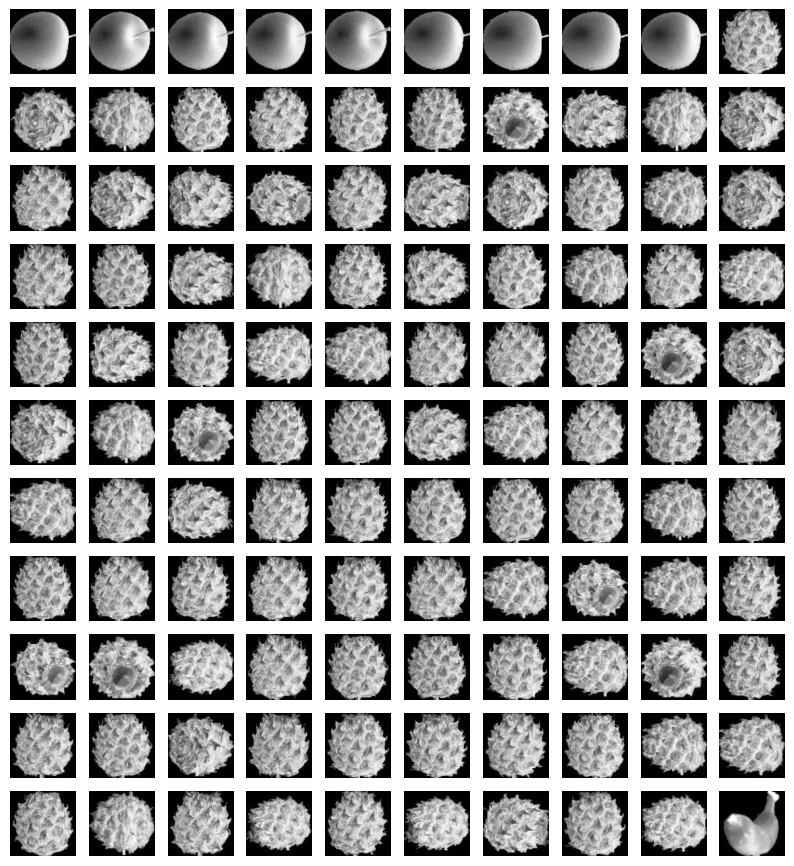

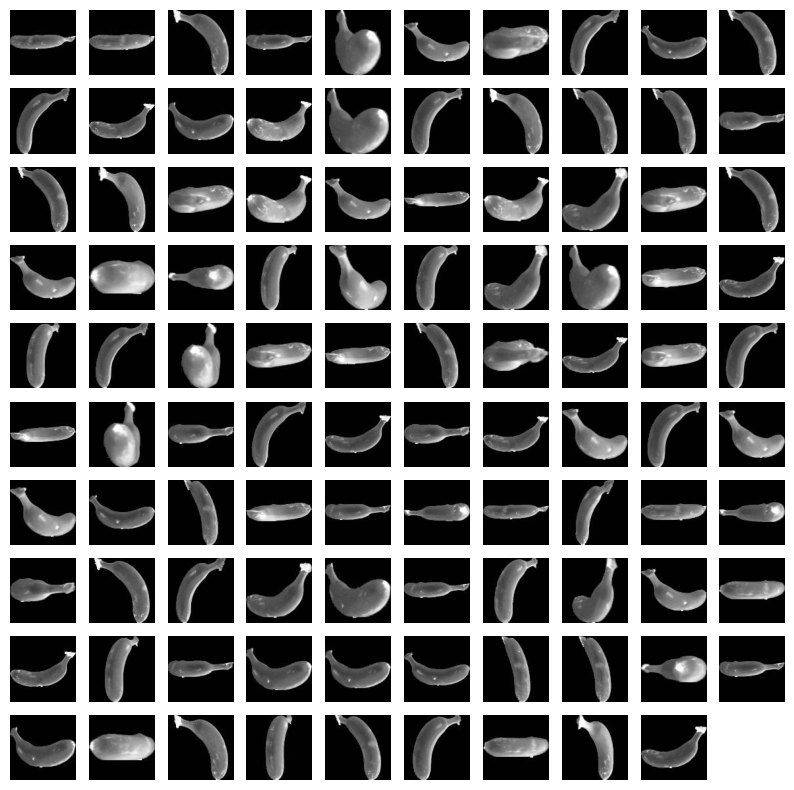

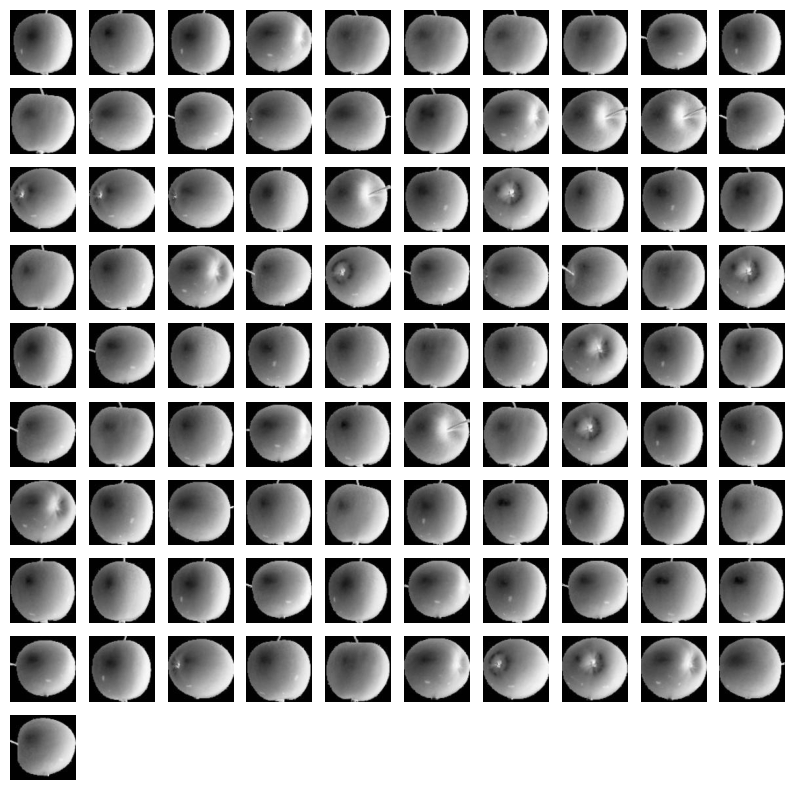

In [43]:
# 그림으로 확인
for label in range(3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

#### 산포도로 확인해 보기

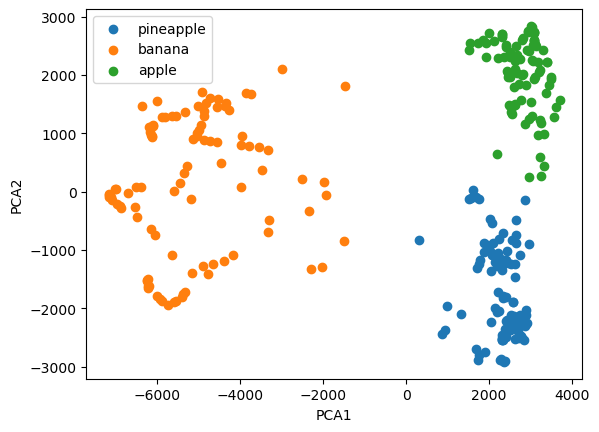

In [45]:
for label in range(3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:,0], data[:,1]) # x:PCA1, y:PCA2

plt.legend(['pineapple', 'banana', 'apple'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show() 

> 현재 PCA는 2개이다.    
뚜렷한 분포가 확인 가능하다.   
즉, 차원이 큰 데이터의 분포를 그래프로 확인할 경우에는 주성분 분석을 활용한다.    